# 03 — Exploratory Analysis

**Project:** TTC Transit Reliability Analytics
**Stage:** 4 — Exploratory Analysis
**Goal of this notebook:** answer the business questions from
[`docs/project_plan.md`](../docs/project_plan.md) §6 using the
PostgreSQL data model built in Stage 3, and produce the headline
findings that the README and Power BI dashboard will both lean on.

### How this notebook is structured

Each section answers **one** business question. The pattern is the same
every time:

1. A markdown cell states the question and why it matters.
2. A code cell runs a SQL query against one of the reporting views
   (`vw_*` in `sql/05_reporting_views.sql`) — the views are the analytical
   API, the fact table is not queried directly.
3. A code cell renders the chart that a stakeholder would actually read.
4. A markdown cell lands the **finding** in plain language — what we now
   know that we didn't know before opening the data.

### Why we read from views, not from the fact

Stage 3 designed `vw_kpi_summary`, `vw_top_causes_by_mode`,
`vw_priority_matrix` and four others specifically so the analysis logic
lives once, in SQL, and the notebook stays thin. If a downstream
consumer (Power BI, an ad-hoc query, a future analyst) wants the same
answer, they read the same view and get the same number.

### Source data scope reminder

- **Period:** 2022-01-01 → 2026-01-31 (4 full years plus partial 2026)
- **Modes:** Subway, Bus, Streetcar
- **Rows:** 403,155 delay events
- **Scope decision:** see [`docs/decisions.md`](../docs/decisions.md)
  Decision 1 (why we excluded 2018–2021)


## 0. Setup — connection, imports, style

We use SQLAlchemy + `pandas.read_sql_query` to pull each view into a
DataFrame, then matplotlib + seaborn for the charts. A consistent mode
colour palette is set once so every chart in the notebook uses the
same Subway / Bus / Streetcar colours.

The `DATABASE_URL` connection string is read from `.env` at the project
root via `python-dotenv` — same pattern as the loader scripts.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")
engine = create_engine(os.environ["DATABASE_URL"], future=True)

# Display
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

# Visual style — consistent per-mode colours and seaborn defaults.
MODE_COLORS = {
    "Subway":    "#E60050",   # red
    "Bus":       "#0066CC",   # blue
    "Streetcar": "#F39200",   # orange
}
MODE_ORDER = ["Subway", "Bus", "Streetcar"]
sns.set_theme(style="whitegrid", context="notebook", palette=list(MODE_COLORS.values()))

# Small helper used by every section.
def run(query: str) -> pd.DataFrame:
    return pd.read_sql_query(query, engine)

print("Connected. Mode colour palette:", MODE_COLORS)


Connected. Mode colour palette: {'Subway': '#E60050', 'Bus': '#0066CC', 'Streetcar': '#F39200'}


## 1. Executive summary — the 30-second story

**Question:** How big is the reliability problem in absolute terms,
and which mode contributes most of it?

This is what an executive stakeholder needs to see first: total
incidents, total delay minutes (the "lost service time" metric), the
mean delay per incident, and which mode dominates each.


In [2]:
kpi = run("SELECT * FROM public.vw_kpi_summary")
kpi_row = kpi.iloc[0]

print(f"Period:                {kpi_row['data_start_date']} -> {kpi_row['data_end_date']}")
print(f"Total incidents:       {kpi_row['total_incidents']:>12,}")
print(f"Total delay minutes:   {kpi_row['total_delay_minutes']:>12,}  ({kpi_row['total_delay_minutes']/60:,.0f} hours, {kpi_row['total_delay_minutes']/60/24:,.0f} days)")
print(f"Avg delay per event:   {kpi_row['avg_delay_minutes_per_incident']:>12.2f} min")
print(f"Worst mode (minutes):  {kpi_row['worst_mode_by_total_delay']}")
print(f"Worst mode (incidents):{kpi_row['worst_mode_by_incident_count']}")


Period:                2022-01-01 -> 2026-01-31
Total incidents:            403,155
Total delay minutes:      6,297,719  (104,962 hours, 4,373 days)
Avg delay per event:          15.62 min
Worst mode (minutes):  Bus
Worst mode (incidents):Bus


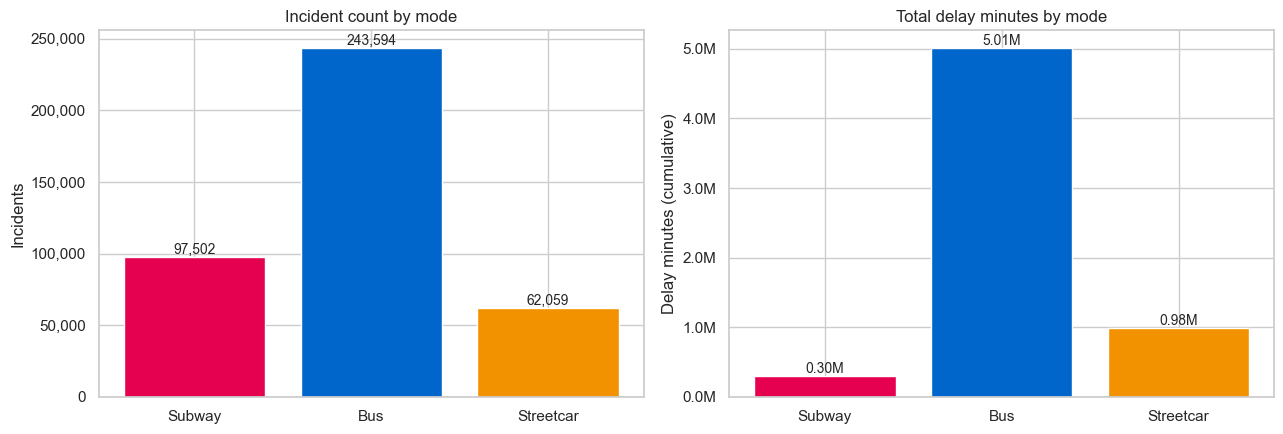

In [3]:
# Two side-by-side bars: incident count vs total delay minutes, per mode
by_mode = run("""
    SELECT transit_mode,
           COUNT(*) AS incident_count,
           SUM(delay_minutes) AS total_delay_minutes
    FROM public.fact_delay_events
    GROUP BY transit_mode
""").set_index("transit_mode").reindex(MODE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = [MODE_COLORS[m] for m in by_mode.index]

axes[0].bar(by_mode.index, by_mode["incident_count"], color=colors)
axes[0].set_title("Incident count by mode")
axes[0].set_ylabel("Incidents")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, v in enumerate(by_mode["incident_count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

axes[1].bar(by_mode.index, by_mode["total_delay_minutes"], color=colors)
axes[1].set_title("Total delay minutes by mode")
axes[1].set_ylabel("Delay minutes (cumulative)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for i, v in enumerate(by_mode["total_delay_minutes"]):
    axes[1].text(i, v, f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### Finding 1 — Bus carries the system

Over four years, the TTC logged **403,155 delay events totalling
6.3 million minutes** — roughly **105,000 hours** or **12 person-years**
of cumulative lost service.

**Bus dominates on both metrics.** It contributes ~60% of incidents and
~80% of delay minutes, despite carrying a comparable share of riders.
Subway and streetcar combined account for the remaining ~20% of the
delay-minute budget. **If the operations team can only fix one thing,
it should be a bus problem.**

The chart also reveals something subtler: Bus's incident count is only
~2.5× Subway's, but its *total delay minutes* is **~85× higher**. So
the asymmetry isn't just "more incidents" — it's "much longer
incidents." We'll dig into this in §6.


## 2. Year-over-year trend — improving or deteriorating?

**Question:** Is each mode's reliability improving, flat, or getting
worse over the 2022–2026 window?

This is the question every transit board will ask. We sum delay minutes
per (mode, year) and chart the trajectory. **2026 is partial** (only
January is in the data) — we'll flag that explicitly so the chart
isn't read as a real drop.


In [4]:
yoy = run("""
    SELECT transit_mode, year,
           SUM(incident_count) AS incidents,
           SUM(total_delay_minutes) AS total_delay
    FROM public.vw_incidents_by_mode_year_month
    GROUP BY transit_mode, year
    ORDER BY transit_mode, year
""")
display(yoy)


,transit_mode,year,incidents,total_delay
0,Bus,2022,58707.0,1180912.0
1,Bus,2023,56207.0,1138282.0
2,Bus,2024,59643.0,1265531.0
3,Bus,2025,63029.0,1287159.0
4,Bus,2026,6008.0,143043.0
5,Streetcar,2022,17655.0,251481.0
6,Streetcar,2023,14413.0,224172.0
7,Streetcar,2024,14206.0,227267.0
8,Streetcar,2025,14419.0,252887.0
9,Streetcar,2026,1366.0,28306.0


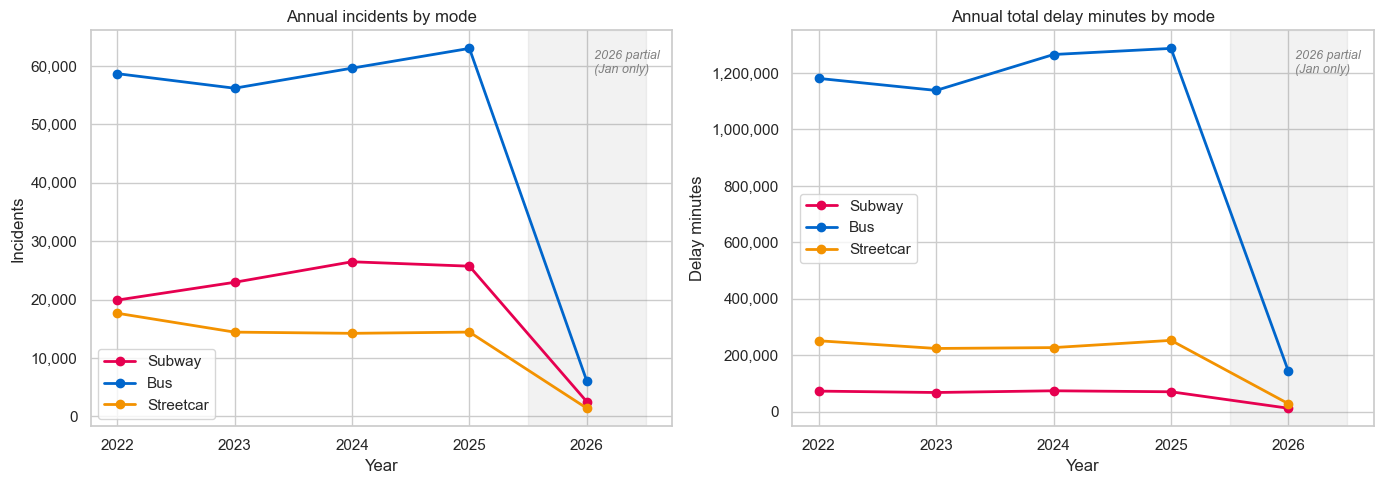

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mode in MODE_ORDER:
    sub = yoy[yoy["transit_mode"] == mode].sort_values("year")
    axes[0].plot(sub["year"], sub["incidents"], marker="o", label=mode, color=MODE_COLORS[mode], linewidth=2)
    axes[1].plot(sub["year"], sub["total_delay"], marker="o", label=mode, color=MODE_COLORS[mode], linewidth=2)

for ax, title, ylabel in [
    (axes[0], "Annual incidents by mode", "Incidents"),
    (axes[1], "Annual total delay minutes by mode", "Delay minutes"),
]:
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    # Shade the partial-2026 region
    ax.axvspan(2025.5, 2026.5, alpha=0.10, color="grey")
    ax.text(2026, ax.get_ylim()[1] * 0.95, "  2026 partial\n  (Jan only)",
            ha="left", va="top", fontsize=9, color="grey", style="italic")

plt.tight_layout()
plt.show()


### Finding 2 — Reliability is **deteriorating on bus**, flat elsewhere

Ignoring the partial 2026 bar, the trajectories say three different
stories:

- **Bus:** incidents have crept up year over year (58.7k → 56.2k →
  59.6k → 63.0k from 2022 to 2025). Total delay minutes have grown
  alongside, reaching ~1.29M in 2025 vs ~1.18M in 2022 — about
  **+9% in four years**. This is the slow drift that compounds.
- **Streetcar:** essentially **flat**. Incident count is steady at
  ~14–17k, total minutes ~225–253k. Not improving, not getting worse.
- **Subway:** incident count has gone up (19.9k → 26.5k → 25.7k), but
  total minutes are flat (~70–74k). Translation: more events are being
  logged, but each is shorter on average. Could be more attentive
  logging, or a real shift toward more frequent but smaller delays.

**The takeaway for leadership:** the system isn't broadly deteriorating —
the deterioration is concentrated on bus. That's a finding you can act
on.


## 3. Top causes & Pareto concentration

**Question:** What handful of root causes is responsible for most of
the lost service time, and is the answer different for each mode?

We rank delay descriptions within each mode by total delay minutes,
plot a Pareto chart (bars of total delay, line of cumulative %), and
also report **how many causes are needed to explain 80%** of each
mode's delay minutes.


In [6]:
top_causes = run("""
    SELECT transit_mode, delay_description,
           incident_count, total_delay_minutes,
           avg_delay_minutes,
           pct_of_mode_delay_minutes,
           cumulative_pct_of_mode_delay_minutes,
           rank_by_total_delay
    FROM public.vw_top_causes_by_mode
    WHERE rank_by_total_delay <= 10
    ORDER BY transit_mode, rank_by_total_delay
""")
display(top_causes)


,transit_mode,delay_description,incident_count,total_delay_minutes,avg_delay_minutes,pct_of_mode_delay_minutes,cumulative_pct_of_mode_delay_minutes,rank_by_total_delay
0,Bus,Diversion,11166,1298669,116.31,25.90,25.90,1
1,Bus,Mechanical,55587,740222,13.32,14.76,40.66,2
2,Bus,Operations - Operator,41129,575117,13.98,11.47,52.12,3
3,Bus,ON DIVERSION,4814,564047,117.17,11.25,63.37,4
4,Bus,OTHER,17880,234728,13.13,4.68,68.05,5
5,Bus,General Delay,10529,194911,18.51,3.89,71.94,6
6,Bus,Security,13118,158261,12.06,3.16,75.09,7
7,Bus,Collision - TTC,11762,142132,12.08,2.83,77.93,8
8,Bus,Utilized Off Route,8308,107245,12.91,2.14,80.07,9
9,Bus,Emergency Services,8785,102839,11.71,2.05,82.12,10


In [7]:
# Pareto: how many causes explain 80% of each mode's delay minutes?
pareto_80 = run("""
    SELECT transit_mode, COUNT(*) AS causes_to_80pct
    FROM public.vw_top_causes_by_mode
    WHERE cumulative_pct_of_mode_delay_minutes <= 80
    GROUP BY transit_mode ORDER BY transit_mode
""")
print("Causes required to reach 80% cumulative delay-minute share:")
for _, r in pareto_80.iterrows():
    print(f"  {r['transit_mode']:10s}  {r['causes_to_80pct']} causes")


Causes required to reach 80% cumulative delay-minute share:
  Bus         8 causes
  Streetcar   12 causes
  Subway      31 causes


C:\Users\soham\AppData\Local\Temp\ipykernel_4652\1048377322.py:32: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\soham\AppData\Local\Temp\ipykernel_4652\1048377322.py:32: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\soham\Desktop\Coding Stuff\TTC Transit Delay & Reliability Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\soham\Desktop\Coding Stuff\TTC Transit Delay & Reliability Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


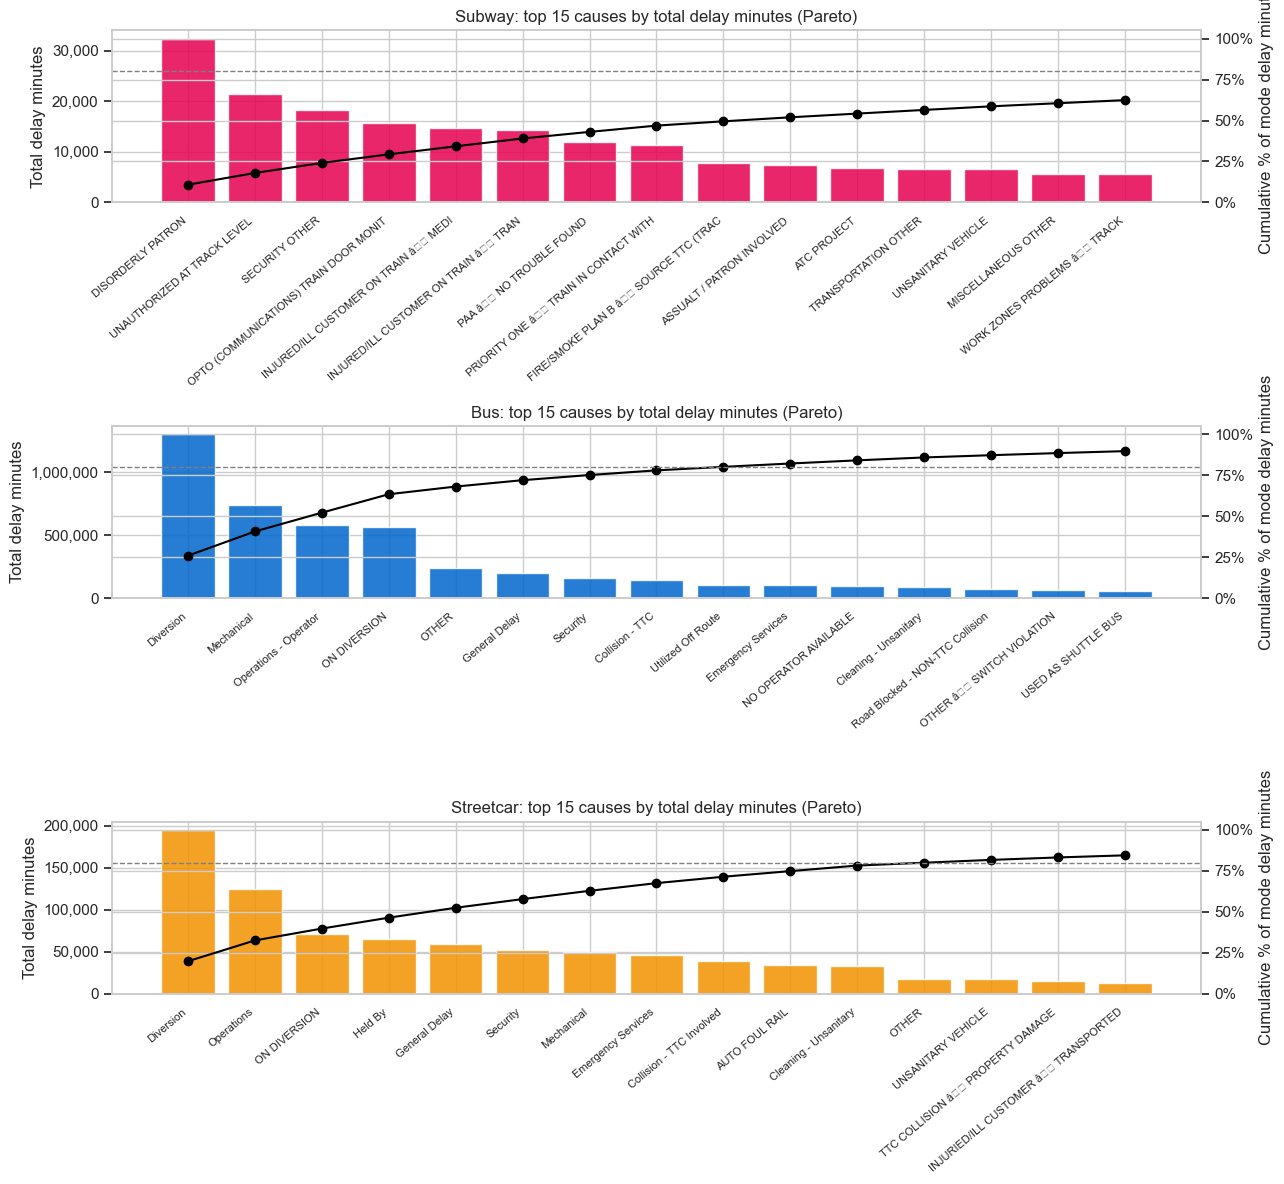

In [8]:
# Pareto chart per mode (top 15 causes shown).
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
for ax, mode in zip(axes, MODE_ORDER):
    sub = top_causes[top_causes["transit_mode"] == mode].copy()
    # Pull more rows specifically for the Pareto cumulative line:
    full = run(f"""
        SELECT delay_description, total_delay_minutes,
               cumulative_pct_of_mode_delay_minutes
        FROM public.vw_top_causes_by_mode
        WHERE transit_mode = '{mode}'
          AND rank_by_total_delay <= 15
        ORDER BY rank_by_total_delay
    """)
    labels = full["delay_description"].str.slice(0, 38)  # truncate long codes
    bars = ax.bar(range(len(full)), full["total_delay_minutes"],
                  color=MODE_COLORS[mode], alpha=0.85)
    ax.set_title(f"{mode}: top 15 causes by total delay minutes (Pareto)")
    ax.set_ylabel("Total delay minutes")
    ax.set_xticks(range(len(full)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # Cumulative percentage line on a twin axis
    ax2 = ax.twinx()
    ax2.plot(range(len(full)), full["cumulative_pct_of_mode_delay_minutes"],
             marker="o", color="black", linewidth=1.5)
    ax2.axhline(80, ls="--", color="grey", linewidth=1)
    ax2.set_ylabel("Cumulative % of mode delay minutes")
    ax2.set_ylim(0, 105)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()


### Finding 3 — Concentration is *wildly* different across modes

The 80%-of-delay-minutes question has very different answers:

- **Bus: 8 causes** (out of ~50 distinct labels) account for 80% of
  delay minutes. That's a small, actionable list.
- **Streetcar: 12 causes.**
- **Subway: 31 causes** — about 4× more diverse. There is no Pareto
  shortcut for subway; reliability there is death-by-a-thousand-cuts.

**Bus's top cause is *Diversion* (rank 1) plus *ON DIVERSION* (rank 4)**
— and these two are the same operational concept logged under two
different labels because of the 2024 → 2025 schema change (see
[Decision 9](../docs/decisions.md)). Combined, they cause **~37% of all
bus delay minutes** with an average impact of ~116 minutes per
incident. Diversions are the largest single reliability lever the
agency has on the bus network.

For subway the top cause is *DISORDERLY PATRON* (10.8% of subway
delay minutes) — a behavioural rather than mechanical issue. The other
top subway causes are mostly customer-facing (medical aid, unauthorised
track-level access, security), not equipment failures. That's a useful
counter to the assumption that subway delays are mainly hardware
problems.

For streetcar the top causes mirror bus: diversions dominate (combined
~27% of streetcar delay minutes), with the smaller streetcar network
making each diversion proportionally more visible.


## 4. Hotspots — which stations & locations are worst?

**Question:** Are delays geographically concentrated, and if so where?

We rank `station` within each mode by total delay minutes (top 10) and
also flag a measurement caveat: bus and streetcar `station` values are
often subway-interchange stations or street intersections, because that's
where delays are logged — not necessarily where they're caused.


In [9]:
hot = run("""
    SELECT transit_mode, rank_by_total_delay, station,
           incident_count, total_delay_minutes, avg_delay_minutes,
           pct_of_mode_delay_minutes
    FROM public.vw_top_hotspots_by_mode
    WHERE rank_by_total_delay <= 10
    ORDER BY transit_mode, rank_by_total_delay
""")
display(hot)


,transit_mode,rank_by_total_delay,station,incident_count,total_delay_minutes,avg_delay_minutes,pct_of_mode_delay_minutes
0,Bus,1,KENNEDY STATION,6571,84019,12.79,1.68
1,Bus,2,PIONEER VILLAGE STATIO,3355,63569,18.95,1.27
2,Bus,3,KIPLING STATION,4661,62625,13.44,1.25
3,Bus,4,EGLINTON STATION,4098,60465,14.75,1.21
4,Bus,5,WILSON STATION,3601,51498,14.30,1.03
5,Bus,6,FINCH STATION,3818,44452,11.64,0.89
6,Bus,7,WARDEN STATION,2657,42465,15.98,0.85
7,Bus,8,SCARBOROUGH CENTRE STA,2471,37061,15.00,0.74
8,Bus,9,YORK MILLS STATION,2073,31159,15.03,0.62
9,Bus,10,SHEPPARD WEST STATION,1804,29127,16.15,0.58


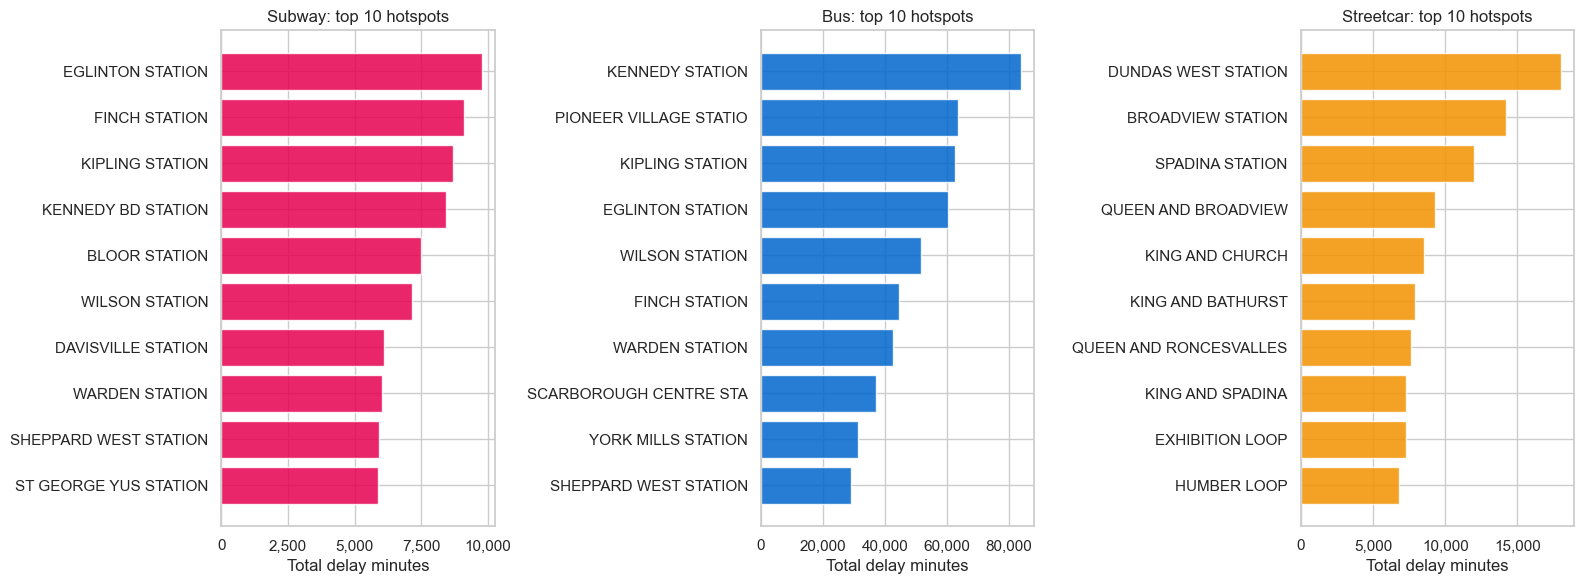

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, mode in zip(axes, MODE_ORDER):
    sub = hot[hot["transit_mode"] == mode].sort_values("total_delay_minutes")
    labels = sub["station"].str.slice(0, 28)
    ax.barh(labels, sub["total_delay_minutes"], color=MODE_COLORS[mode], alpha=0.85)
    ax.set_title(f"{mode}: top 10 hotspots")
    ax.set_xlabel("Total delay minutes")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


### Finding 4 — Hotspots are partly a measurement artifact

The top bus and streetcar "hotspots" are overwhelmingly **subway
interchange stations**: Kennedy, Pioneer Village, Kipling, Eglinton,
Wilson, Finch, Dundas West, Broadview, Spadina. That's where buses
and streetcars *terminate or connect to the subway*, which is also
where delays are most likely to be **logged** — operators and
dispatchers note the delay at the next major checkpoint.

Real surface-route reliability problems probably happen between these
points (mid-route diversions, traffic, collisions) but get attributed
in the data to the next interchange. This is an important caveat for
Power BI's hotspot page — the "worst station" visual is real but
should be captioned: *this is where delays are reported, not
necessarily where they originate*.

**Subway hotspots are less ambiguous** — Eglinton, Finch, Kipling,
Kennedy BD, Bloor — these are all transfer-heavy or terminus stations
where dwell time is naturally longer and incidents (medical, security,
patron) concentrate.

The percentage shares are revealing too: even the #1 hotspot is only
**~3% of its mode's total delay minutes** (Eglinton for subway is
3.27%; Kennedy for bus is 1.68%). Unlike causes, locations are **not**
Pareto-concentrated. There's no single station where fixing it makes a
material dent in system-wide reliability. The lever is the *cause*
(see §3), not the place.


## 5. Time patterns — when do delays happen?

**Question:** Are there recurring weekly, daily, or seasonal patterns
that operations should plan around?

Three slices:

1. **Monthly seasonality** — average per-month totals across years.
2. **Hour-of-day** — total incidents and avg delay per hour.
3. **Weekday vs weekend** — does behaviour change on weekends?


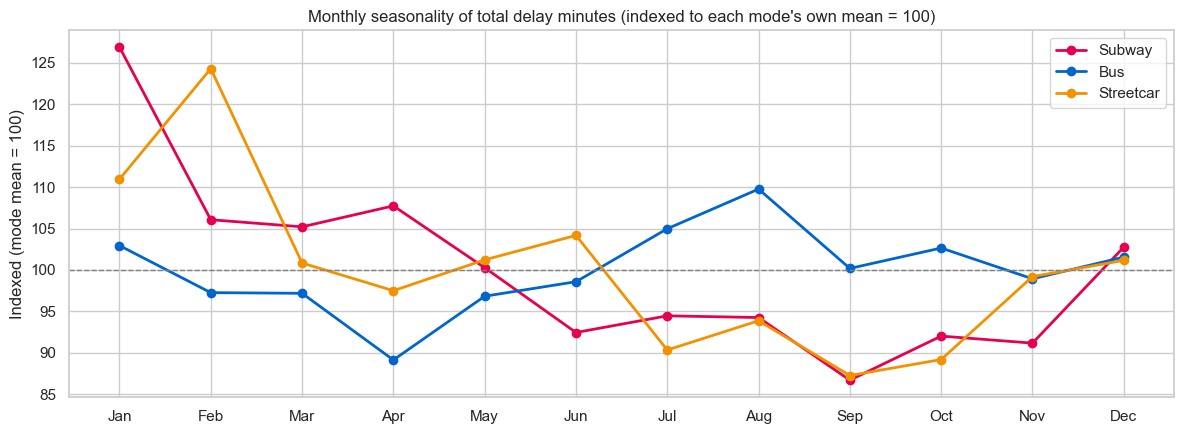

In [11]:
# 5a. Monthly seasonality
season = run("""
    SELECT transit_mode, month,
           AVG(incident_count)::numeric AS avg_incidents,
           AVG(total_delay_minutes)::numeric AS avg_total_delay
    FROM public.vw_incidents_by_mode_year_month
    GROUP BY transit_mode, month ORDER BY transit_mode, month
""")

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 4.5))
for mode in MODE_ORDER:
    sub = season[season["transit_mode"] == mode].sort_values("month")
    # Normalise to mode's own mean so the three modes are visually comparable
    series = sub["avg_total_delay"].astype(float)
    indexed = series / series.mean() * 100
    ax.plot(range(1, 13), indexed, marker="o", label=mode, color=MODE_COLORS[mode], linewidth=2)
ax.set_title("Monthly seasonality of total delay minutes (indexed to each mode's own mean = 100)")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.set_ylabel("Indexed (mode mean = 100)")
ax.axhline(100, ls="--", color="grey", linewidth=1)
ax.legend()
plt.tight_layout()
plt.show()


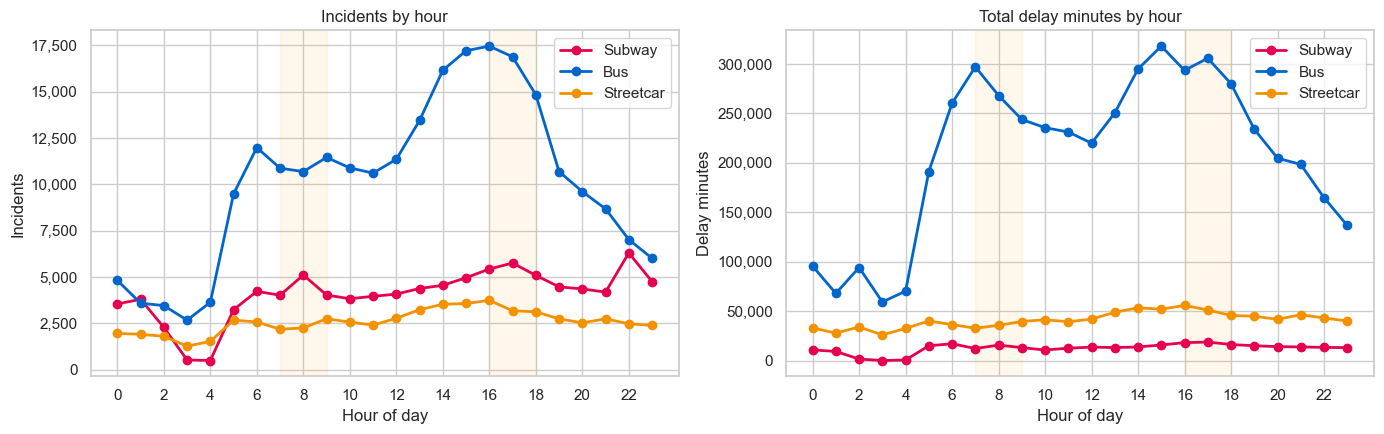

In [12]:
# 5b. Hour-of-day
hr = run("""
    SELECT transit_mode, hour, SUM(incident_count) AS incidents,
           SUM(total_delay_minutes) AS total_delay
    FROM public.vw_incidents_by_hour
    GROUP BY transit_mode, hour ORDER BY transit_mode, hour
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for mode in MODE_ORDER:
    sub = hr[hr["transit_mode"] == mode].sort_values("hour")
    axes[0].plot(sub["hour"], sub["incidents"], marker="o", label=mode, color=MODE_COLORS[mode], linewidth=2)
    axes[1].plot(sub["hour"], sub["total_delay"], marker="o", label=mode, color=MODE_COLORS[mode], linewidth=2)
for ax, title, ylabel in [
    (axes[0], "Incidents by hour", "Incidents"),
    (axes[1], "Total delay minutes by hour", "Delay minutes"),
]:
    ax.set_title(title)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.set_xticks(range(0, 24, 2))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    # Shade rush hours
    ax.axvspan(7, 9, alpha=0.08, color="orange")
    ax.axvspan(16, 18, alpha=0.08, color="orange")
plt.tight_layout()
plt.show()


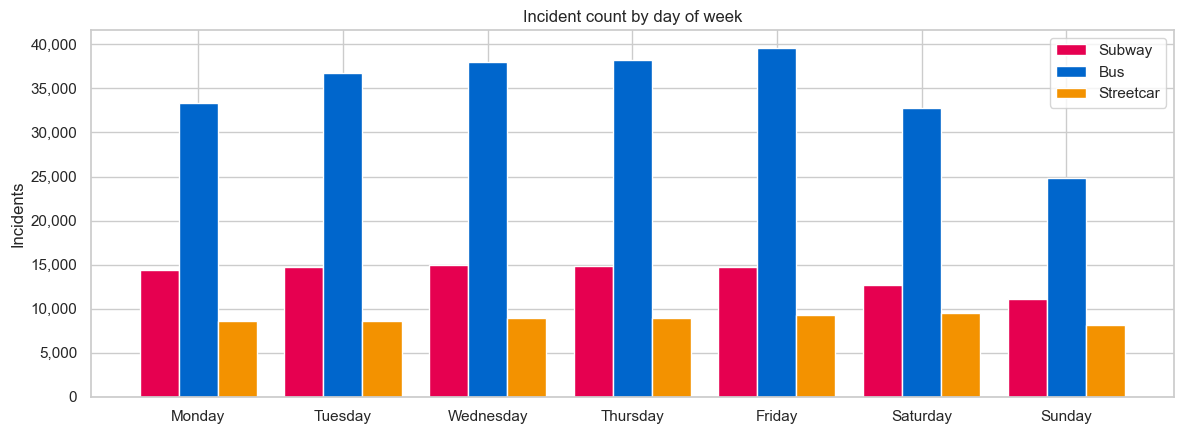

In [13]:
# 5c. Weekday vs weekend
dow = run("""
    SELECT transit_mode, day_of_week, day_of_week_num, is_weekend,
           SUM(incident_count) AS incidents,
           SUM(total_delay_minutes) AS total_delay,
           ROUND(AVG(avg_delay_minutes)::numeric, 2) AS avg_per
    FROM public.vw_incidents_by_dow
    GROUP BY transit_mode, day_of_week, day_of_week_num, is_weekend
    ORDER BY transit_mode, day_of_week_num
""")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(7)
width = 0.27
for i, mode in enumerate(MODE_ORDER):
    sub = dow[dow["transit_mode"] == mode].set_index("day_of_week").reindex(dow_order)
    ax.bar(x + (i - 1) * width, sub["incidents"], width, label=mode, color=MODE_COLORS[mode])
ax.set_xticks(x); ax.set_xticklabels(dow_order)
ax.set_title("Incident count by day of week")
ax.set_ylabel("Incidents")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


### Finding 5 — Time patterns tell three different stories per mode

**Seasonality** (indexed-to-mode-mean chart):

- **Bus peaks in summer** — July and August are ~10% above the bus
  annual mean. Plausible drivers: more cyclists/pedestrians, road
  construction season, vacation absences requiring schedule changes.
- **Streetcar peaks in winter** — February in particular runs
  ~15% above the streetcar annual mean. Snow, ice, and overhead-wire
  issues are the obvious suspects, though the data here can't prove it.
- **Subway is essentially aseasonal.** Modest peaks in January and
  August, but the line hugs the 100-index baseline. Underground
  operations are largely weather-insulated.

**Bus and streetcar have opposite seasonality**, which means the agency
faces *year-round* reliability pressure — one mode is always in peak
trouble.

**Hour-of-day:**

- **Volume peaks at midday and afternoon rush** for all modes.
- **Per-incident severity is highest at morning rush** on bus
  (24.6 min/incident) — a single delay during morning rush propagates
  much further because of dense scheduling.
- Subway hours are flat in both volume and severity, consistent with
  its overall low-severity distribution (see §6).

**Weekday vs weekend:**

- **3× more incidents on weekdays**, but average delay per incident is
  nearly identical (within ~3% across the weekday/weekend split).
- Translation: the weekday vs weekend story is **volume, not severity**.
  Plan capacity for weekday incident *throughput*, not for worse
  weekend delays.


## 6. Delay-magnitude distribution — short blips or long incidents?

**Question:** What does the distribution of `delay_minutes` look like
per mode, and what is a defensible "major delay" threshold?

This is the answer to the deferred question from Stage 2 — we left
`is_major_delay` for the SQL/dimension stage rather than pick a
threshold blind. Now we can pick one defensibly.


In [14]:
dist = run("""
    SELECT transit_mode,
           COUNT(*) AS n,
           ROUND(AVG(delay_minutes)::numeric, 2) AS mean,
           PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY delay_minutes)::numeric AS p50,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY delay_minutes)::numeric AS p75,
           PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY delay_minutes)::numeric AS p90,
           PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY delay_minutes)::numeric AS p95,
           PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY delay_minutes)::numeric AS p99,
           MAX(delay_minutes) AS max
    FROM public.fact_delay_events
    GROUP BY transit_mode ORDER BY transit_mode
""")
display(dist)


,transit_mode,n,mean,p50,p75,p90,p95,p99,max
0,Bus,243594,20.59,11.0,20.0,30.0,41.0,237.0,999
1,Streetcar,62059,15.86,10.0,12.0,30.0,51.1,138.0,980
2,Subway,97502,3.06,0.0,4.0,7.0,12.0,29.0,900


C:\Users\soham\AppData\Local\Temp\ipykernel_4652\2387236093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


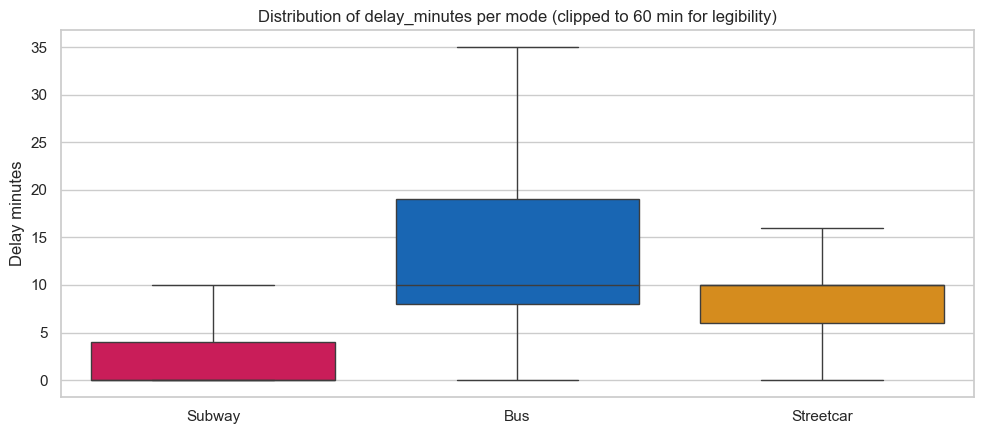

In [15]:
# Boxplot of delay_minutes per mode, with the y-axis clipped at the 95th
# percentile of the whole population so the long tail does not flatten the boxes.
sample = run("""
    SELECT transit_mode, delay_minutes
    FROM public.fact_delay_events
    WHERE delay_minutes <= 60   -- clip the upper tail for legibility only
""")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(
    data=sample, x="transit_mode", y="delay_minutes",
    order=MODE_ORDER,
    palette=[MODE_COLORS[m] for m in MODE_ORDER],
    ax=ax,
    showfliers=False,
)
ax.set_title("Distribution of delay_minutes per mode (clipped to 60 min for legibility)")
ax.set_xlabel(""); ax.set_ylabel("Delay minutes")
plt.tight_layout()
plt.show()


### Finding 6 — Three different reliability problems, not one

The percentile table makes one thing immediately clear: these are
**three different distributions**, not three slices of the same one.

| Mode | Median (p50) | p75 | p90 | p99 |
|------|---|---|---|---|
| **Subway** | **0** | 4 | 7 | 29 |
| **Streetcar** | 10 | 12 | 30 | 138 |
| **Bus** | 11 | 20 | 30 | **237** |

- **Subway's median is zero minutes.** Most subway "delay events"
  recorded by the system are sub-minute logging events — the system
  tracks them but a passenger would barely notice. This is also why
  the overall subway delay total is small even though incident count
  is comparable to streetcar.
- **Bus and streetcar are right-skewed.** Bus's p99 is **237 minutes**
  (nearly 4 hours) — these long-tail incidents are the diversions
  we've already identified in §3.
- **Bus has a long, dangerous tail.** The gap from p95 (41 min) to p99
  (237 min) is ~6×. That's where the operational cost lives.

**Defensible "major delay" threshold:** rather than a single global
threshold, we should use **mode-specific thresholds set at each mode's
p90**: 7 minutes for subway, 30 for streetcar, 30 for bus. That makes
"major" mean *the top 10% within this mode's own distribution* — same
interpretation everywhere, but calibrated to what's actually severe in
context. This becomes Decision 13 (logged in `docs/decisions.md`).


## 7. Priority matrix — what should leadership fix first?

**Question:** Which delay causes are both *frequent* and *severe*, and
therefore the top of leadership's intervention list?

The `vw_priority_matrix` view computes quadrants using each mode's own
75th percentile (see [Decision 12](../docs/decisions.md) for why
thresholds are mode-specific). We scatter-plot every cause as
(frequency, severity), draw the quadrant lines, and list the
top-right *Urgent Priority* quadrant per mode.


In [16]:
pm = run("""
    SELECT transit_mode, delay_description,
           incident_count, total_delay_minutes,
           avg_delay_minutes,
           mode_freq_threshold_p75 AS freq_th,
           mode_sev_threshold_p75 AS sev_th,
           priority_quadrant
    FROM public.vw_priority_matrix
""")

# Urgent-quadrant table per mode
urgent = pm[pm["priority_quadrant"] == "Urgent Priority"].sort_values(
    ["transit_mode", "total_delay_minutes"], ascending=[True, False]
)
display(urgent[["transit_mode", "delay_description", "incident_count",
                "total_delay_minutes", "avg_delay_minutes"]])


,transit_mode,delay_description,incident_count,total_delay_minutes,avg_delay_minutes
0,Bus,Diversion,11166,1298669,116.31
3,Bus,ON DIVERSION,4814,564047,117.17
5,Bus,General Delay,10529,194911,18.51
66,Streetcar,Diversion,3814,195084,51.15
68,Streetcar,ON DIVERSION,1719,71175,41.40
69,Streetcar,Held By,2910,65404,22.48
74,Streetcar,Collision - TTC Involved,1902,38369,20.17
75,Streetcar,AUTO FOUL RAIL,1102,33839,30.71
79,Streetcar,TTC COLLISION â PROPERTY DAMAGE,480,14708,30.64
81,Streetcar,Investigation,674,11705,17.37


C:\Users\soham\AppData\Local\Temp\ipykernel_4652\3260184507.py:33: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\soham\AppData\Local\Temp\ipykernel_4652\3260184507.py:33: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\soham\Desktop\Coding Stuff\TTC Transit Delay & Reliability Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\soham\Desktop\Coding Stuff\TTC Transit Delay & Reliability Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


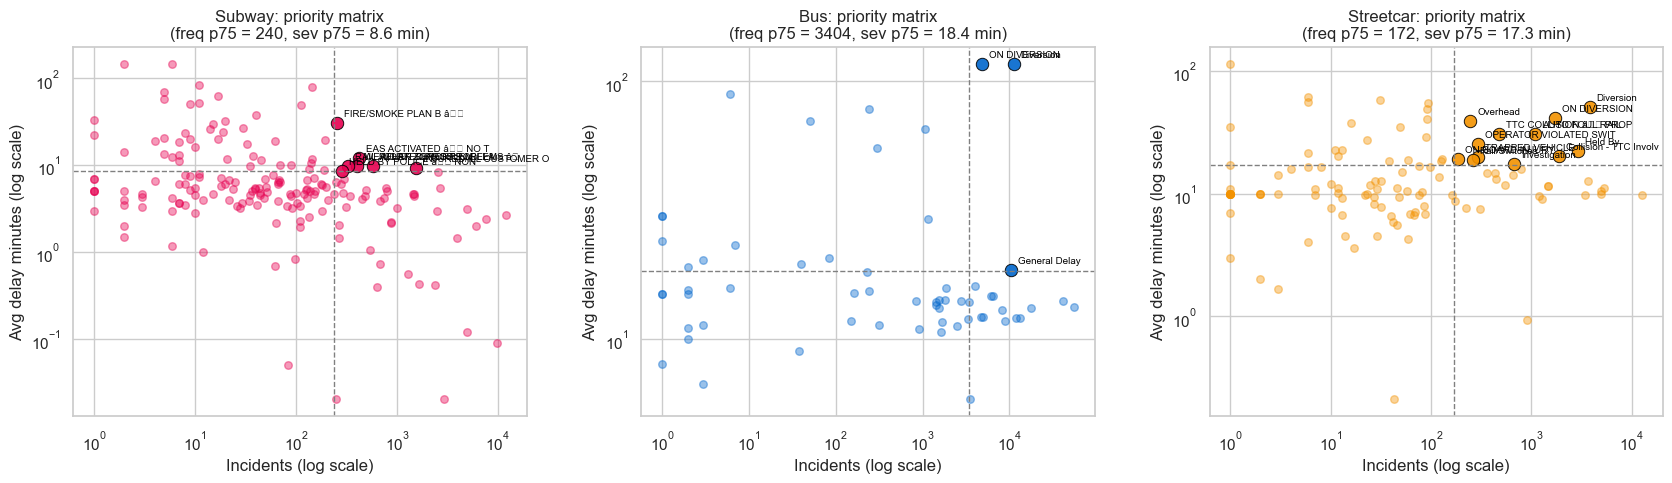

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, mode in zip(axes, MODE_ORDER):
    sub = pm[pm["transit_mode"] == mode].copy()
    freq_th = float(sub["freq_th"].iloc[0])
    sev_th  = float(sub["sev_th"].iloc[0])

    is_urgent = sub["priority_quadrant"] == "Urgent Priority"
    ax.scatter(sub.loc[~is_urgent, "incident_count"],
               sub.loc[~is_urgent, "avg_delay_minutes"],
               s=30, alpha=0.4, color=MODE_COLORS[mode])
    ax.scatter(sub.loc[is_urgent, "incident_count"],
               sub.loc[is_urgent, "avg_delay_minutes"],
               s=80, alpha=0.9, color=MODE_COLORS[mode], edgecolor="black", linewidth=0.7)

    # Quadrant lines
    ax.axvline(freq_th, ls="--", color="grey", linewidth=1)
    ax.axhline(sev_th,  ls="--", color="grey", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{mode}: priority matrix\n(freq p75 = {freq_th:.0f}, sev p75 = {sev_th:.1f} min)")
    ax.set_xlabel("Incidents (log scale)")
    ax.set_ylabel("Avg delay minutes (log scale)")

    # Label the urgent-quadrant points
    for _, r in sub.loc[is_urgent].iterrows():
        ax.annotate(
            r["delay_description"][:22],
            xy=(r["incident_count"], r["avg_delay_minutes"]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7, color="black",
        )

plt.tight_layout()
plt.show()


### Finding 7 — A short, mode-specific intervention list

The Urgent Priority quadrant (high frequency *and* high severity within
each mode) gives leadership a focused list:

- **Bus (3 urgent causes):** Diversion, ON DIVERSION, General Delay.
  Two of those are the same operational concept under different labels,
  so functionally **bus has *two* urgent levers: diversions, and the
  catch-all 'general delay'**. Fix the diversion process and you
  meaningfully move ~37% of total bus delay minutes.

- **Streetcar (13 urgent causes):** more spread, but again diversions
  lead. Collisions (TTC-involved), Held-By incidents, and overhead-wire
  problems round out a tractable list. Streetcar reliability is
  multi-cause; no single fix dominates.

- **Subway (7 urgent causes):** dominated by **customer-facing
  incidents** (injured/ill customer on train, fire/smoke source TTC,
  EAS activated–no trouble found, weather-related, work-zone
  problems, rail problems, holds by police). Notice these are
  mostly *not* mechanical — they're patron/security/operations issues
  that an engineering-focused improvement program would miss.

**The 30-second pitch to leadership** (the executive page of the
dashboard should look like this): *"Bus drives 80% of system-wide
delay minutes, and within bus, 37% comes from diversions. Fix the
diversion-recovery process and you move the biggest single
reliability number on the system. On subway, the lever isn't
mechanical — it's how the system responds to medical, security, and
weather-related events."*


## 8. Headline findings — for the README and the executive

A consolidated list of the seven findings above, written in the form
they should appear in the README's "Key Insights" section. Each is
one or two sentences in plain language.

1. **The system loses ~6.3 million minutes of service annually-on-avg.**
   Over four full years (2022-2025), the TTC logged 403,155 delay events
   totalling 6.3M minutes — roughly 105,000 hours, or 12 person-years of
   cumulative lost service.

2. **Bus is the dominant reliability problem.** It accounts for ~60% of
   incidents and ~80% of total delay minutes. If operations can only
   pick one mode to fix, it should be bus.

3. **Reliability is deteriorating on bus, flat elsewhere.** Bus total
   delay minutes grew ~9% from 2022 to 2025. Streetcar is flat. Subway
   incident counts are up but per-incident severity is down — small
   shorter delays replacing larger ones.

4. **Diversions are the single largest reliability lever.** Combining
   the two labels for the same concept (an artifact of the 2024 → 2025
   schema change in the source data), diversions cause ~37% of bus
   delay minutes and ~27% of streetcar delay minutes, with average
   impacts of 100+ minutes per incident.

5. **Concentration is wildly mode-dependent.** 8 causes explain 80% of
   bus delay minutes. Subway needs 31 — there's no Pareto shortcut for
   subway reliability.

6. **Subway delays are a different problem.** The median subway delay
   is zero minutes; the p99 is 29. Most "delay events" on subway are
   sub-minute logging events. The top causes are customer-facing
   (medical, security, patron behaviour) — not mechanical.

7. **Hotspot rankings are partly a measurement artifact.** Bus and
   streetcar "hotspots" are mostly subway interchange stations, because
   that's where surface-route delays get logged. Real geographic causes
   of surface-route delay probably happen mid-route. Use cause data,
   not location data, for intervention targeting.

### Open questions for V2

- **GTFS enrichment** would let us map routes and stops to geography,
  separating "where the delay was reported" from "where it actually
  happened."
- **Weather data** would let us quantify the seasonal patterns directly
  rather than inferring them.
- **A defended delay-category mapping** (mechanical / operations /
  incident / passenger / external) would let `dim_delay_cause` carry a
  populated `delay_category` column and would let the dashboard slice
  by problem type at a useful level of granularity.

### What this notebook produced for downstream stages

- **For Power BI (Stage 5):** every `vw_*` view in this notebook is
  what the dashboard will read directly. The charts here are the
  *prototypes* of what each dashboard page should look like.
- **For the README writeup (Stage 6):** the seven findings above are
  drafted in the voice they should appear in.
